# Customer Lifetime Value (CLV) Prediction — Feature Engineering

## Notebook Objective

This notebook transforms cleaned transaction-level retail data into a customer-level modeling table for **Customer Lifetime Value (CLV)** prediction.

The notebook is designed to support a **senior-level, production-oriented ML workflow**. It focuses on building a defensible supervised learning dataset rather than simply generating arbitrary features.

## What this notebook will do

- load the cleaned transaction dataset produced during EDA
- confirm the usable transaction time span
- define a time-based modeling framework
- split the data into **observation** and **prediction** windows
- engineer customer behavior features from historical transactions only
- construct a **future CLV target** from later transactions
- assemble a final modeling table for model training
- validate the modeling table and save it for downstream use
    
## Modeling Principle

To prevent **target leakage**:

- all **features** are built strictly from the **observation window**
- the **target** is built strictly from the **future / prediction window**

## Section 1 — Load Libraries and Input Data

### What this section does
This section imports the required libraries and loads the cleaned transaction dataset created in the EDA stage.

### What should already be true
At this point, the input data should already be:

- standardized to consistent column names
- deduplicated
- restricted to valid positive transactions
- filtered to rows with known customer IDs

### Why this matters
Feature engineering should begin from a trusted analytical base. If noisy operational records are left in the data, customer-level features such as revenue, frequency, and recency will be distorted.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

df_clean = pd.read_csv(
    "../data/processed/online_retail_clean.csv",
    parse_dates=["invoice_date"]
)

df_clean.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,invoice_month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


### Interpretation

The feature engineering process begins from the cleaned transaction dataset rather than the raw file. This is important because customer-level CLV features are highly sensitive to upstream data quality issues.

Using the cleaned dataset ensures that the modeling table will reflect **actual positive purchase behavior**, not duplication artifacts, cancellations, or unidentifiable customers.

## Section 2 — Confirm Dataset Coverage Period

### What this section does
This section checks the start date, end date, and total time span covered by the cleaned transactional data.

### Why this matters
A time-based supervised learning setup requires enough history to:

- build meaningful historical features
- hold out a future period for target construction
- preserve a realistic chronology between past behavior and future value

The date span determines whether the observation and prediction windows are feasible.

In [2]:
date_summary = pd.DataFrame({
    "metric": ["min_invoice_date", "max_invoice_date", "date_span_days"],
    "value": [
        df_clean["invoice_date"].min(),
        df_clean["invoice_date"].max(),
        (df_clean["invoice_date"].max() - df_clean["invoice_date"].min()).days
    ]
})

date_summary

,metric,value
0,min_invoice_date,2010-12-01 08:26:00
1,max_invoice_date,2011-12-09 12:50:00
2,date_span_days,373


### Interpretation

The cleaned dataset spans **373 days**, from **2010-12-01 08:26:00** to **2011-12-09 12:50:00**.

This is sufficient for a time-based CLV modeling design because the data contains:

- a long enough history window for customer behavior summarization
- a separate forward-looking window for target definition

From a business perspective, this means the project can simulate a realistic use case: observe customer behavior over time, then estimate the value customers generate afterward.

## Section 3 — Define the Time-Based Modeling Framework

### What this section does
This section formalizes how CLV will be framed for supervised machine learning.

### Modeling definition used here
For this project:

\> **future_clv = total customer revenue generated during a future prediction horizon**

### Why this framing is strong
This approach is realistic and business-relevant because:

- it predicts actual future monetary value
- it aligns with customer retention and revenue prioritization use cases
- it avoids leakage by separating historical inputs from future outcomes

In [3]:
prediction_days = 90
observation_days = 180

max_date = df_clean["invoice_date"].max().normalize()
prediction_start = max_date - pd.Timedelta(days=prediction_days) + pd.Timedelta(days=1)
observation_start = prediction_start - pd.Timedelta(days=observation_days)

window_summary = pd.DataFrame({
    "window": ["observation_start", "prediction_start", "max_date"],
    "date": [observation_start, prediction_start, max_date]
})

window_summary

,window,date
0,observation_start,2011-03-15
1,prediction_start,2011-09-11
2,max_date,2011-12-09


### Interpretation

The modeling window was defined as:

- **Observation window:** 180 days
- **Prediction window:** 90 days

This produces the following timeline:

- observation starts on **2011-03-15**
- prediction starts on **2011-09-11**
- available data ends on **2011-12-09**

This is a strong first-pass design because the model gets roughly **six months of customer behavior** and is asked to predict **three months of future value**. That balance is practical for CLV modeling: it gives enough history to engineer meaningful behavioral features while preserving a non-trivial future target horizon.

## Section 4 — Split Transactions into Observation and Future Windows

### What this section does
This section creates two transaction-level datasets:

- `observation_df`: historical transactions used for feature engineering
- `future_df`: later transactions used for target construction

### Why this matters
This is the core anti-leakage step in the notebook. Once the split is defined, all features must be built from `observation_df` only.

In [4]:
observation_df = df_clean[
    (df_clean["invoice_date"] >= observation_start) &
    (df_clean["invoice_date"] < prediction_start)
].copy()

future_df = df_clean[
    (df_clean["invoice_date"] >= prediction_start) &
    (df_clean["invoice_date"] <= max_date)
].copy()

print("Observation shape:", observation_df.shape)
print("Future shape:", future_df.shape)

Observation shape: (156477, 10)
Future shape: (158242, 10)


### Interpretation

The split produced:

- **156,477** transactions in the observation window
- **158,242** transactions in the prediction window

Both windows contain substantial transaction volume, which is a good sign for modeling stability. This means the feature set will be built from a rich base of historical behavior, and the target will also be grounded in substantial future customer activity rather than a sparse holdout period.

## Section 5 — Compare Coverage Across the Two Windows

### What this section does
This section compares customer counts, transaction counts, and revenue between the observation and prediction windows.

### Why this matters
A useful modeling setup should preserve enough activity in both windows:

- enough history for feature engineering
- enough future purchases for target definition

It also helps reveal whether there are customers who appear in the future period but do not have enough prior history to score.

In [5]:
window_customer_summary = pd.DataFrame({
    "dataset": ["observation", "future"],
    "unique_customers": [
        observation_df["customer_id"].nunique(),
        future_df["customer_id"].nunique()
    ],
    "transactions": [
        len(observation_df),
        len(future_df)
    ],
    "revenue": [
        observation_df["revenue"].sum(),
        future_df["revenue"].sum()
    ]
})

window_customer_summary

,dataset,unique_customers,transactions,revenue
0,observation,2784,156477,3617949.282
1,future,2886,158242,3259900.592


### Interpretation

The two windows show strong commercial activity:

**Observation window**
- customers: **2,784**
- transactions: **156,477**
- revenue: **3,617,949.28**

**Prediction window**
- customers: **2,886**
- transactions: **158,242**
- revenue: **3,259,900.59**

This is a healthy split for a CLV project. The observation period contains enough historical behavior to build meaningful customer features, while the prediction period contains enough future activity to support a useful target.

One important modeling implication is that some customers appear only in the future period. Those customers cannot be used for supervised training in this setup, because the business would not yet have enough historical behavior to create features for them at scoring time.

## Section 6 — Build Customer-Level Features from the Observation Window

### What this section does
This section aggregates the historical transaction data into a **one-row-per-customer** feature table.

### Feature groups created
The initial feature set captures:

- historical spend
- purchase frequency
- quantity purchased
- relationship timing
- product breadth
- price behavior
- geographic breadth

### Why this matters
CLV is not determined by a single metric. A robust model needs a structured summary of how recently, how often, and how much a customer has purchased.

In [6]:
snapshot_date = prediction_start

customer_features = (
    observation_df.groupby("customer_id")
    .agg(
        total_revenue=("revenue", "sum"),
        total_orders=("invoice_no", "nunique"),
        total_items=("quantity", "sum"),
        first_purchase=("invoice_date", "min"),
        last_purchase=("invoice_date", "max"),
        avg_line_revenue=("revenue", "mean"),
        avg_unit_price=("unit_price", "mean"),
        unique_products=("stock_code", "nunique"),
        unique_countries=("country", "nunique")
    )
    .reset_index()
)

customer_features["customer_tenure_days"] = (
    customer_features["last_purchase"] - customer_features["first_purchase"]
).dt.days

customer_features["recency_days"] = (
    snapshot_date - customer_features["last_purchase"]
).dt.days

customer_features["avg_revenue_per_order"] = (
    customer_features["total_revenue"] / customer_features["total_orders"]
)

customer_features.head()

,customer_id,total_revenue,total_orders,total_items,first_purchase,last_purchase,avg_line_revenue,avg_unit_price,unique_products,unique_countries,customer_tenure_days,recency_days,avg_revenue_per_order
0,12347,1603.68,3,956,2011-04-07 10:43:00,2011-08-02 08:48:00,25.057500,2.877344,50,1,116,39,534.56
1,12348,367.00,1,269,2011-04-05 10:47:00,2011-04-05 10:47:00,73.400000,8.920000,5,1,0,158,367.00
2,12352,280.66,2,127,2011-03-17 16:00:00,2011-03-22 16:08:00,18.710667,4.892000,8,1,5,172,140.33
3,12353,89.00,1,20,2011-05-19 17:47:00,2011-05-19 17:47:00,22.250000,6.075000,4,1,0,114,89.00
4,12354,1079.40,1,530,2011-04-21 13:11:00,2011-04-21 13:11:00,18.610345,4.503793,58,1,0,142,1079.40


### Interpretation

The feature table now contains one row per customer, with historical behavior summarized from the observation window only.

The engineered variables reflect several dimensions of customer value:

- `total_revenue` captures cumulative spend
- `total_orders` captures ordering frequency
- `total_items` captures purchase volume
- `recency_days` captures how recently the customer last transacted
- `customer_tenure_days` captures relationship depth
- `avg_revenue_per_order` captures spending intensity
- `unique_products` captures product breadth

## Section 7 — Add Purchase Cadence Features

### What this section does
This section adds features that describe **how regularly** customers purchase over time.

### Why this matters
Two customers may have spent the same amount historically, but their expected future value can still differ if:

- one buys consistently over time
- the other bought in one short burst and then stopped

Cadence features help the model distinguish those patterns.

In [7]:
active_days = (
    observation_df.groupby("customer_id")["invoice_date"]
    .nunique()
    .reset_index(name="active_days")
)

customer_features = customer_features.merge(active_days, on="customer_id", how="left")

customer_features["avg_days_between_orders"] = np.where(
    customer_features["total_orders"] > 1,
    customer_features["customer_tenure_days"] / (customer_features["total_orders"] - 1),
    customer_features["customer_tenure_days"]
)

customer_features.head()

,customer_id,total_revenue,total_orders,total_items,first_purchase,last_purchase,avg_line_revenue,avg_unit_price,unique_products,unique_countries,customer_tenure_days,recency_days,avg_revenue_per_order,active_days,avg_days_between_orders
0,12347,1603.68,3,956,2011-04-07 10:43:00,2011-08-02 08:48:00,25.057500,2.877344,50,1,116,39,534.56,3,58.0
1,12348,367.00,1,269,2011-04-05 10:47:00,2011-04-05 10:47:00,73.400000,8.920000,5,1,0,158,367.00,1,0.0
2,12352,280.66,2,127,2011-03-17 16:00:00,2011-03-22 16:08:00,18.710667,4.892000,8,1,5,172,140.33,2,5.0
3,12353,89.00,1,20,2011-05-19 17:47:00,2011-05-19 17:47:00,22.250000,6.075000,4,1,0,114,89.00,1,0.0
4,12354,1079.40,1,530,2011-04-21 13:11:00,2011-04-21 13:11:00,18.610345,4.503793,58,1,0,142,1079.40,1,0.0


### Interpretation

Two additional cadence-oriented variables were added:

- `active_days`: number of distinct days with purchase activity
- `avg_days_between_orders`: average spacing between orders

These are valuable because CLV is influenced not only by total spend, but also by **consistency of engagement**. Customers with repeated activity over time are often more stable and more likely to generate future value than customers whose spend is concentrated in a single short episode.

## Section 8 — Create the Future Target

### What this section does
This section constructs the supervised learning target from the prediction window.

### Target created
- `future_clv`: total future revenue over the 90-day prediction horizon
- `future_orders`: number of unique future orders

### Why this matters
This target directly represents the outcome the business cares about: how much value a customer will generate after the historical observation period.

In [8]:
future_target = (
    future_df.groupby("customer_id")
    .agg(
        future_clv=("revenue", "sum"),
        future_orders=("invoice_no", "nunique")
    )
    .reset_index()
)

future_target.head()

,customer_id,future_clv,future_orders
0,12347,1519.14,2
1,12348,310.00,1
2,12349,1757.55,1
3,12352,944.23,3
4,12356,58.35,1


### Interpretation

The target table captures realized future customer value rather than a proxy score or handcrafted label.

That makes the problem definition especially strong from a business standpoint:

- it is directly revenue-linked
- it supports prioritization of high-value customers
- it can later be used for retention, targeting, and forecasting workflows

The additional `future_orders` field is useful as a supporting outcome and can also help with analysis or alternate modeling strategies later.

## Section 9 — Assemble the Modeling Table

### What this section does
This section merges the historical feature table with the future target table.

### Join logic used
A **left join** is performed from the historical customer feature table to the future target table.

### Why this is correct
This ensures:

- every customer with observation-period history is retained
- customers with no future purchases are kept in the dataset
- zero future spend is treated as a meaningful business outcome, not a missing-data problem

In [9]:
modeling_df = customer_features.merge(
    future_target,
    on="customer_id",
    how="left"
)

modeling_df["future_clv"] = modeling_df["future_clv"].fillna(0)
modeling_df["future_orders"] = modeling_df["future_orders"].fillna(0).astype(int)

print(modeling_df.shape)
modeling_df.head()

(2784, 17)


,customer_id,total_revenue,total_orders,total_items,first_purchase,last_purchase,avg_line_revenue,avg_unit_price,unique_products,unique_countries,customer_tenure_days,recency_days,avg_revenue_per_order,active_days,avg_days_between_orders,future_clv,future_orders
0,12347,1603.68,3,956,2011-04-07 10:43:00,2011-08-02 08:48:00,25.057500,2.877344,50,1,116,39,534.56,3,58.0,1519.14,2
1,12348,367.00,1,269,2011-04-05 10:47:00,2011-04-05 10:47:00,73.400000,8.920000,5,1,0,158,367.00,1,0.0,310.00,1
2,12352,280.66,2,127,2011-03-17 16:00:00,2011-03-22 16:08:00,18.710667,4.892000,8,1,5,172,140.33,2,5.0,944.23,3
3,12353,89.00,1,20,2011-05-19 17:47:00,2011-05-19 17:47:00,22.250000,6.075000,4,1,0,114,89.00,1,0.0,0.00,0
4,12354,1079.40,1,530,2011-04-21 13:11:00,2011-04-21 13:11:00,18.610345,4.503793,58,1,0,142,1079.40,1,0.0,0.00,0


### Interpretation

The assembled modeling table contains **2,784 customers** and **17 columns**.

This is the correct supervised learning structure for CLV modeling:

- one row per customer
- historical features on the left
- future outcomes on the right

Filling missing future values with zero is appropriate here because customers who did not purchase again during the prediction window actually genuinely generated **zero future value** in that horizon.

## Feature Engineering — Behavioral Intensity & Normalized Metrics

In addition to aggregate customer features, we derive behavioral intensity features that capture:

- spending rate over time  
- purchase frequency relative to tenure  
- recency relative to customer lifetime  
- basket size efficiency  

These features provide a more dynamic view of customer behavior and are expected to improve model performance by capturing **behavioral patterns rather than static totals**.

In [10]:
# Prevent division issues
modeling_df["customer_tenure_days_adj"] = modeling_df["customer_tenure_days"].replace(0, 1)
modeling_df["total_orders_adj"] = modeling_df["total_orders"].replace(0, 1)

# Behavioral intensity features
modeling_df["revenue_per_day"] = (
    modeling_df["total_revenue"] / modeling_df["customer_tenure_days_adj"]
)

modeling_df["orders_per_day"] = (
    modeling_df["total_orders"] / modeling_df["customer_tenure_days_adj"]
)

modeling_df["recency_ratio"] = (
    modeling_df["recency_days"] / modeling_df["customer_tenure_days_adj"]
)

modeling_df["items_per_order"] = (
    modeling_df["total_items"] / modeling_df["total_orders_adj"]
)

## Section 10 — Assess the Target Distribution

### What this section does
This section examines the statistical distribution of `future_clv`.

### Why this matters
Revenue targets are typically highly skewed. Before modeling, it is important to understand:

- how many customers have zero future value
- how concentrated the target is
- whether extreme outliers are present
- whether target transformation may be needed later

In [11]:
target_summary = modeling_df["future_clv"].describe().to_frame().T
target_summary

,count,mean,std,min,25%,50%,75%,max
future_clv,2784.0,919.377946,4475.309694,0.0,0.0,251.04,794.7875,123737.11


In [12]:
zero_clv_pct = (modeling_df["future_clv"] == 0).mean() * 100
print(f"Customers with zero future CLV: {zero_clv_pct:.2f}%")

Customers with zero future CLV: 38.22%


### Zero-Value Customers

Approximately **38.22% of customers** generated zero revenue in the prediction window.

### Interpretation
This means a significant portion of customers became inactive or did not return within the prediction period.

### Business implication
This is effectively a **churn signal**:
- many customers do not make repeat purchases
- retention is a major driver of revenue

### Modeling implication
This suggests that CLV prediction contains two sub-problems:

1. **Will the customer return? (classification)**
2. **If they return, how much will they spend? (regression)**

For this project, we proceed with a regression approach, but this insight opens the door for:
- two-stage models (classification + regression)
- churn prediction systems
- retention-focused strategies

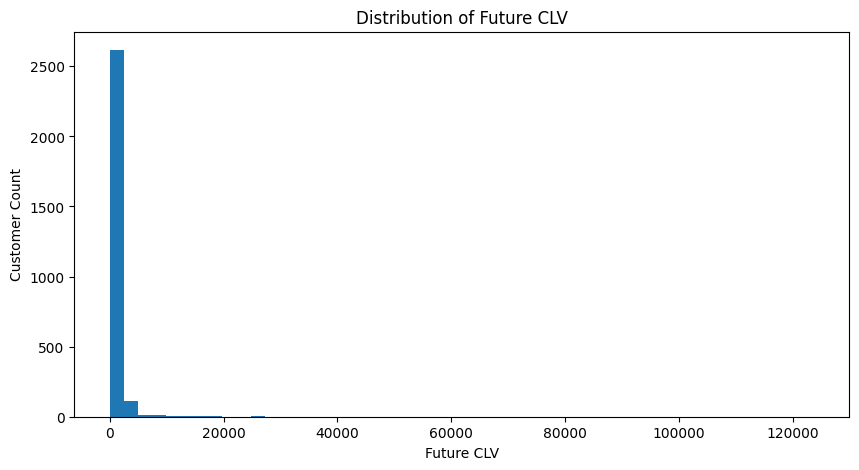

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(modeling_df["future_clv"], bins=50)
plt.title("Distribution of Future CLV")
plt.xlabel("Future CLV")
plt.ylabel("Customer Count")
plt.show()

### Target Distribution (Raw CLV)

The distribution of future customer lifetime value is **extremely right-skewed**.

### Key observations
- A large proportion of customers generate very low or zero future revenue
- A small minority of customers generate extremely high revenue (long tail)
- The maximum CLV exceeds 120,000, while most values are close to zero

### Business interpretation
This reflects a common real-world pattern:
- most customers are low-value or inactive
- a small group of high-value customers drives a large portion of revenue

### Modeling implication
This level of skewness presents challenges for regression models:
- models may be dominated by extreme high-value outliers
- prediction errors on large customers can disproportionately affect metrics
- linear models may struggle to fit the distribution effectively

This motivates the need for **target transformation**.

- using **MAE** and **RMSE** together
- checking model performance on high-value customers separately

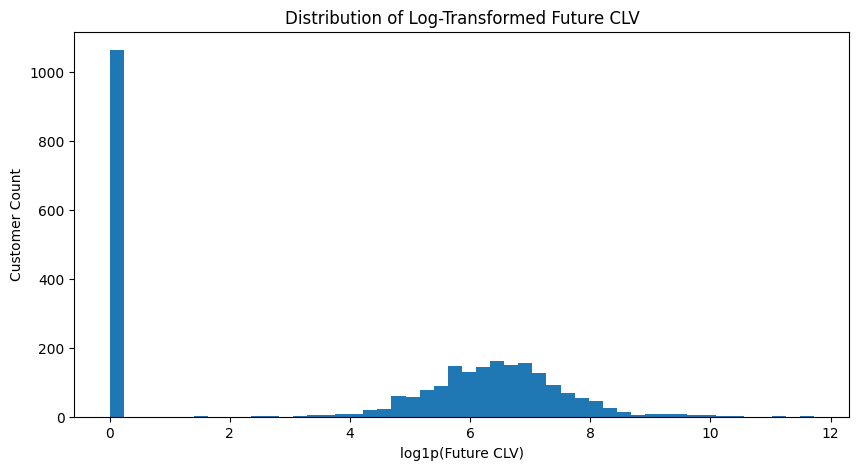

In [14]:
plt.figure(figsize=(10, 5))
plt.hist(np.log1p(modeling_df["future_clv"]), bins=50)
plt.title("Distribution of Log-Transformed Future CLV")
plt.xlabel("log1p(Future CLV)")
plt.ylabel("Customer Count")
plt.show()

### Interpretation (Log-Transformed CLV)

After applying a log transformation (`log1p`), the distribution of future CLV becomes significantly more balanced.

### Key observations
- extreme outliers are compressed
- the distribution becomes more symmetric
- variance is reduced across the range of values
- zero values remain at zero (log1p handles this safely)

### Business interpretation
The transformation preserves the relative ranking of customers while reducing the dominance of extreme high-value users.

### Modeling implication
Using a log-transformed target can improve model performance by:
- stabilizing variance
- reducing sensitivity to outliers
- enabling better generalization across customer segments

Predictions can later be transformed back to the original scale using:
exp(prediction) - 1

## Section 11 — Validate Modeling Table Quality

### What this section does
This section performs final checks on the assembled customer-level modeling dataset.

### What we want to confirm
- one row per customer
- no missing values
- a fully defined target
- business-valid zero future CLV values

In [15]:
modeling_quality = pd.DataFrame({
    "metric": [
        "rows",
        "unique_customers",
        "missing_values_total",
        "customers_with_zero_future_clv"
    ],
    "value": [
        len(modeling_df),
        modeling_df["customer_id"].nunique(),
        modeling_df.isna().sum().sum(),
        (modeling_df["future_clv"] == 0).sum()
    ]
})

modeling_quality

,metric,value
0,rows,2784
1,unique_customers,2784
2,missing_values_total,0
3,customers_with_zero_future_clv,1064


### Interpretation

The modeling table passes the primary quality checks:

- rows: **2,784**
- unique customers: **2,784**
- total missing values: **0**
- customers with zero future CLV: **1,064**

This means the dataset is **clean and model-ready**:

- each customer appears once
- no feature or target values are missing
- zero future CLV reflects a valid business outcome, not an error

This type of structure is expected before moving into modeling phase.

## Section 12 — Finalize the Modeling Dataset

### What this section does
This section selects the final columns to carry into the modeling stage.

### Why this matters
The final training table should contain:

- only customer-level identifiers and model-ready features
- no unnecessary raw datetime anchor columns
- well-defined target variables for downstream training

In [16]:
final_modeling_df = modeling_df[[
    "customer_id",
    "total_revenue",
    "total_orders",
    "total_items",
    "avg_line_revenue",
    "avg_unit_price",
    "unique_products",
    "unique_countries",
    "customer_tenure_days",
    "recency_days",
    "avg_revenue_per_order",
    "active_days",
    "avg_days_between_orders",
    "revenue_per_day",
    "orders_per_day",
    "recency_ratio",
    "items_per_order",

    "future_orders",
    "future_clv"
]].copy()

final_modeling_df["customer_id"] = final_modeling_df["customer_id"].astype(str)

final_modeling_df.head()

,customer_id,total_revenue,total_orders,total_items,avg_line_revenue,avg_unit_price,unique_products,unique_countries,customer_tenure_days,recency_days,avg_revenue_per_order,active_days,avg_days_between_orders,revenue_per_day,orders_per_day,recency_ratio,items_per_order,future_orders,future_clv
0,12347,1603.68,3,956,25.057500,2.877344,50,1,116,39,534.56,3,58.0,13.824828,0.025862,0.336207,318.666667,2,1519.14
1,12348,367.00,1,269,73.400000,8.920000,5,1,0,158,367.00,1,0.0,367.000000,1.000000,158.000000,269.000000,1,310.00
2,12352,280.66,2,127,18.710667,4.892000,8,1,5,172,140.33,2,5.0,56.132000,0.400000,34.400000,63.500000,3,944.23
3,12353,89.00,1,20,22.250000,6.075000,4,1,0,114,89.00,1,0.0,89.000000,1.000000,114.000000,20.000000,0,0.00
4,12354,1079.40,1,530,18.610345,4.503793,58,1,0,142,1079.40,1,0.0,1079.400000,1.000000,142.000000,530.000000,0,0.00


### Interpretation

The final modeling dataset includes a focused set of customer-level behavioral predictors plus two future outcomes:

- `future_orders`
- `future_clv`

This is the clean format for the modeling stage. It preserves the most important explanatory signals while excluding raw date fields that were only needed during intermediate calculations.

## Section 13 — Save the Modeling Dataset

### What this section does
This section saves the final modeling table to the processed data directory.

### Why this matters
Saving the output creates a reproducible boundary between:

- feature engineering
- model training
- deployment and inference workflows

In [17]:
output_path = Path("../data/processed/customer_modeling_table.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

final_modeling_df.to_csv(output_path, index=False)

print(f"Saved to: {output_path}")

Saved to: ..\data\processed\customer_modeling_table.csv


## Final Target Engineering Decision

Based on the observed distribution of the target variable:

- the raw CLV is highly right-skewed
- a large proportion of customers have zero future value
- extreme outliers exist among high-value customers

### Final decision

The model will be trained using:

log1p(future_clv)

This transformation improves model stability and performance while preserving the relative ordering of customer value.

Predictions will be transformed back to the original scale for interpretation.

# Feature Engineering Conclusion

## What this notebook accomplished

This notebook transformed cleaned transaction-level retail data into a customer-level supervised learning table for CLV prediction.

Specifically, it:

- confirmed the usable transaction coverage period
- defined a realistic observation/prediction window framework
- built customer behavior features from historical transactions only
- created a future revenue target from later transactions
- assembled a clean final modeling dataset with no missing values
- saved that dataset for downstream model training

## Final dataset summary

- customers in modeling table: **2,784**
- total missing values: **0**
- customers with zero future CLV: **1,064**
- percentage with zero future CLV: **38.22%**

## Business significance

The final table reflects a realistic CLV use case:
the business observes historical customer behavior and predicts how much revenue that customer will generate in the next 90 days.

This is what is needed for the next stage of the project:
**model training, evaluation, and deployment-oriented interpretation**.